# skforecast Integration Example

This notebook demonstrates how to use xeries with skforecast's `ForecasterRecursiveMultiSeries` (0.21+).

You must pass the same `series` you used in `fit(series=...)` into `from_skforecast(..., series=...)` or `get_training_data(series=...)`, because skforecast's `create_train_X_y` requires it.

**Note:** This notebook requires the `skforecast` optional dependency:
```bash
pip install xeries[skforecast]
```

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Check if skforecast is available
try:
    from skforecast.recursive import ForecasterRecursiveMultiSeries
    SKFORECAST_AVAILABLE = True
except ImportError:
    SKFORECAST_AVAILABLE = False
    print("skforecast not installed. Install with: pip install xeries[skforecast]")

## 1. Create Sample Data

In [2]:
np.random.seed(42)
n_periods = 500
dates = pd.date_range('2023-01-01', periods=n_periods, freq='h')

series_data = {}
for i in range(3):
    series_id = f'MT_{i+1:03d}'
    base = np.random.randn() * 10
    trend = np.linspace(0, 5, n_periods)
    seasonal = 5 * np.sin(2 * np.pi * np.arange(n_periods) / 24)
    noise = np.random.randn(n_periods) * 0.5
    series_data[series_id] = base + trend + seasonal + noise

df = pd.DataFrame(series_data, index=dates)
print(f"Data shape: {df.shape}")
df.head()

Data shape: (500, 3)


,MT_001,MT_002,MT_003
2023-01-01 00:00:00,4.898009,18.394883,0.272835
2023-01-01 01:00:00,6.595101,20.679766,2.249531
2023-01-01 02:00:00,8.248697,21.288885,3.313086
2023-01-01 03:00:00,8.415659,22.416198,4.609494
2023-01-01 04:00:00,9.220280,23.168177,5.284097


## 2. Train ForecasterRecursiveMultiSeries

In [4]:
from sklearn.preprocessing import StandardScaler

if SKFORECAST_AVAILABLE:
    forecaster = ForecasterRecursiveMultiSeries(
        estimator=RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            random_state=42
        ),
        lags=12,
        transformer_series=StandardScaler(),
        transformer_exog=StandardScaler()
    )
    forecaster.fit(series=df)
    print(f"Forecaster fitted with {forecaster.estimator.n_features_in_} features")
else:
    print("Skipping: skforecast not available")

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\skforecast\utils\ │
│ utils.py:2568                                                                        │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Forecaster fitted with 13 features


## 3. Create Adapter and Extract Training Data

In [ ]:
forecaster.summary

<bound method ForecasterBase.summary of ============================== 
ForecasterRecursiveMultiSeries 
Estimator: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12] 
Window features: None 
Window size: 12 
Series encoding: ordinal 
Series names (levels): MT_001, MT_002, MT_003 
Exogenous included: False 
Exogenous names: None 
Transformer for series: None 
Transformer for exog: None 
Weight function included: False 
Series weights: None 
Differentiation order: None 
Training range: 
    'MT_001': ['2023-01-01 00:00:00', '2023-01-21 19:00:00'], 'MT_002': ['2023-01-01
    00:00:00', '2023-01-21 19:00:00'], 'MT_003': ['2023-01-01 00:00:00',
    '2023-01-21 19:00:00'] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 

In [ ]:
if SKFORECAST_AVAILABLE:
    from xeries.adapters.skforecast import from_skforecast

    # Same `series` as fit(series=...) — required by skforecast.create_train_X_y
    adapter = from_skforecast(forecaster, series=df)
    X, y = adapter.get_training_data()
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Features: {adapter.get_feature_names()}")
    print(f"Series IDs: {adapter.get_series_ids()}")
else:
    print("Skipping: skforecast not available")

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\skforecast\utils\ │
│ utils.py:2568                                                                        │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

X shape: (1464, 13)
y shape: (1464,)
Features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12']
Series IDs: ['MT_001', 'MT_002', 'MT_003']


## 4. Compute Conditional Importance

In [ ]:
if SKFORECAST_AVAILABLE:
    from xeries import ConditionalPermutationImportance
    
    explainer = ConditionalPermutationImportance(
        model=adapter,
        metric='mse',
        strategy='auto',
        n_repeats=3,
        n_jobs=1,
        random_state=42,
    )
    
    result = explainer.explain(X, y)
    print("\nFeature Importance:")
    display(result.to_dataframe())
else:
    print("Skipping: skforecast not available")

c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: Use


Feature Importance:


c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


,feature,importance,std
0,lag_1,2.801604,0.087068
1,lag_2,0.132047,0.006684
11,lag_12,0.063954,0.000914
2,lag_3,0.047909,0.001679
3,lag_4,0.044758,0.003520
5,lag_6,0.043046,0.001627
6,lag_7,0.032445,0.000440
7,lag_8,0.030646,0.000909
4,lag_5,0.028300,0.000491
10,lag_11,0.027875,0.000901


## 5. Visualize Results

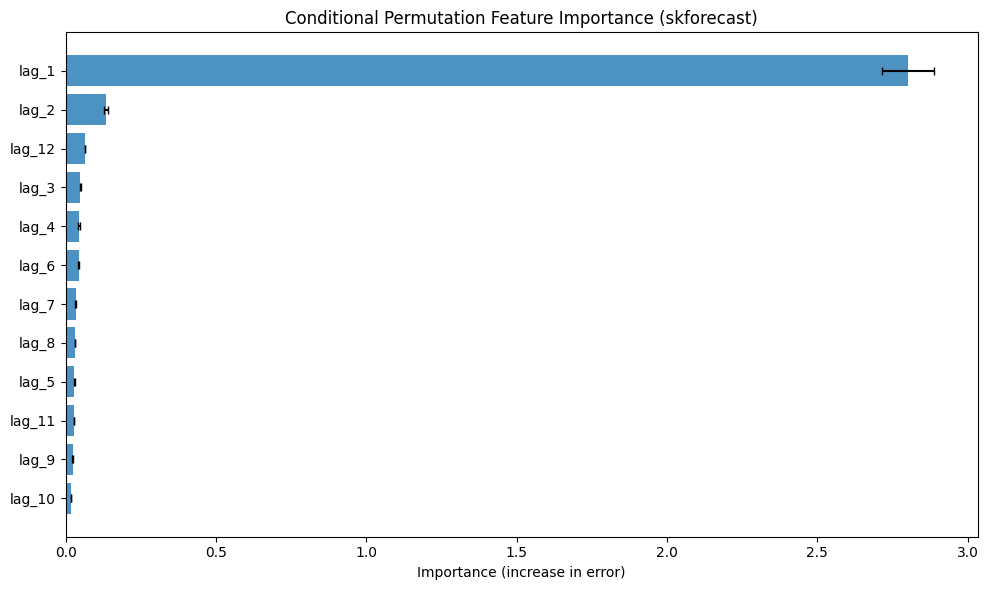

In [ ]:
if SKFORECAST_AVAILABLE:
    from xeries.visualization import plot_importance_bar
    
    fig, ax = plot_importance_bar(
        result,
        max_features=12,
        title='Conditional Permutation Feature Importance (skforecast)'
    )
else:
    print("Skipping: skforecast not available")

x## Summary

This notebook demonstrated the seamless integration between xeries and skforecast:

1. Train a `ForecasterRecursiveMultiSeries` model
2. Create a `SkforecastAdapter` with `from_skforecast(forecaster, series=...)` (same series as `fit`)
3. Extract training data via `adapter.get_training_data()`
4. Use the adapter directly with `ConditionalPermutationImportance`

The adapter handles all the complexity of extracting the training matrix and providing predictions in the format expected by xeries.